# Ex7 — Particle tracking: sequences with Brownian motion and focus drift

Tracking networks learn from movies whose ground truth is known frame by frame. This example
simulates particles diffusing in a thin chamber, blinking, while the microscope's focus drifts,
and renders the movie on an EMCCD camera together with a per-frame emitter table.

- **Trajectories are the caller's.** Diffusion, blinking and drift are a few lines of plain
  torch; gradix takes the resulting per-frame values (`position [B, T, N, 3]`,
  `photons [B, T, N]`, `focus [B, T]`) and renders them.
- **Frames are an acquisition.** `gx.acq.Frames(T, interval, exposure)` gives the Chain its time
  axis; every per-frame field follows it, including the objective's focus, which is a per-frame
  *setting*.
- **Labels come with the images**, in the same frame and pixel convention: the table's positions
  are exactly where the spots are rendered.

**Level** L3 (a Chain and a Pipeline) · **Prerequisites** T1 · **Runtime** a few seconds on
a GPU. `SMOKE` (set by the test suite) shrinks the movie, so the notebook also runs in
seconds on a CPU.

In [1]:
import math
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.ticker import NullFormatter

import gradix as gx

SMOKE = os.environ.get("GRADIX_SMOKE") == "1"
DEVICE = "cuda" if torch.cuda.is_available() and not SMOKE else "cpu"
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.titlesize": 9})
g = torch.Generator().manual_seed(4)


def to_numpy(t: torch.Tensor) -> np.ndarray:
    """Return a CPU NumPy copy of a tensor, for plotting."""
    return t.detach().cpu().numpy()

## 1. Trajectories in plain torch

Each particle has its own diffusion coefficient (log-uniform from 0.03 to 0.5 µm²/s), moves
in a chamber 1 µm deep (reflecting walls in z), and blinks as a two-state Markov chain. The focal
plane drifts slowly, as a stage does, so spots grow and shrink while the particles move.

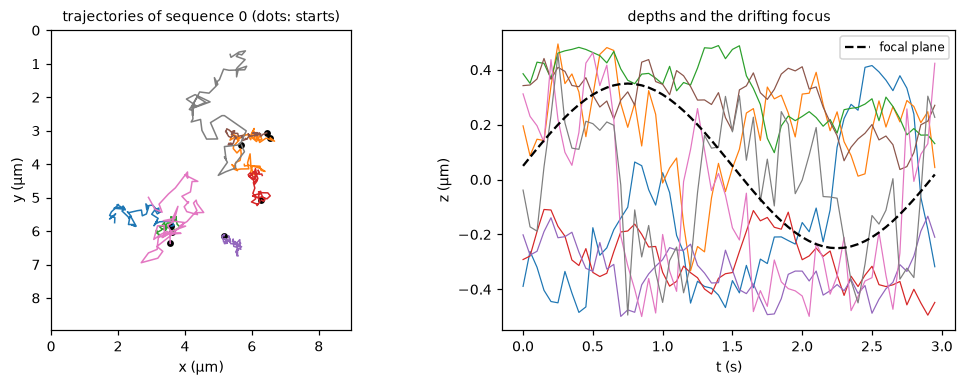

In [2]:
B, T, N = (1, 8, 4) if SMOKE else (4, 60, 8)
dt = 0.05  # s between frames
camera = gx.Camera(
    pixel_size=16.0,
    shape=(32, 32) if SMOKE else (56, 56),
    noise=gx.noise.EMCCD(gain=100.0, read=30.0),
)
fov = gx.coords.field_of_view(camera, gx.Objective(NA=1.2, magnification=100))

D = 10 ** (
    math.log10(0.03) + (math.log10(0.5) - math.log10(0.03)) * torch.rand(B, 1, N, 1, generator=g)
)
start = torch.cat(
    [
        (0.25 + 0.5 * torch.rand(B, 1, N, 2, generator=g)) * fov,
        0.8 * torch.rand(B, 1, N, 1, generator=g) - 0.4,
    ],
    -1,
)
steps = torch.sqrt(2 * D * dt) * torch.randn(B, T, N, 3, generator=g)
steps[:, 0] = 0.0
position = start + steps.cumsum(dim=1)
z = position[..., 2]  # reflect into the chamber |z| ≤ 0.5 µm: fold the walk back at the walls
z = torch.remainder(z + 0.5, 2.0)
position[..., 2] = torch.where(z > 1.0, 2.0 - z, z) - 0.5

on = torch.ones(B, T, N)
for t in range(1, T):  # blinking: 5 % chance to switch off, 30 % to switch back on, per frame
    u = torch.rand(B, N, generator=g)
    on[:, t] = torch.where(on[:, t - 1] > 0, (u > 0.05).float(), (u < 0.3).float())
photons = 1200.0 * on
time = dt * torch.arange(T)
focus = (0.3 * torch.sin(2 * math.pi * time / (T * dt)) + 0.05).expand(B, T)  # µm, per frame

fig, (left, right) = plt.subplots(1, 2, figsize=(9.0, 3.4), layout="constrained")
for n in range(N):
    xy = to_numpy(position[0, :, n, :2])
    left.plot(xy[:, 0], xy[:, 1], lw=1.0)
    left.scatter(xy[0, 0], xy[0, 1], s=12, color="k")
left.set_aspect("equal")
left.set_xlim(0, float(fov[0]))
left.set_ylim(float(fov[1]), 0)
left.set_xlabel("x (µm)")
left.set_ylabel("y (µm)")
left.set_title("trajectories of sequence 0 (dots: starts)")
for n in range(N):
    right.plot(to_numpy(time), to_numpy(position[0, :, n, 2]), lw=0.8)
right.plot(to_numpy(time), to_numpy(focus[0]), "k--", lw=1.5, label="focal plane")
right.set_xlabel("t (s)")
right.set_ylabel("z (µm)")
right.set_title("depths and the drifting focus")
right.legend(fontsize=8)
plt.show()

## 2. Render the movie

The Chain gets an acquisition, `gx.acq.Frames(T, interval, exposure)`, and fields with a
per-frame axis: positions and photons per frame, and the objective's `focus` per frame (a
setting, `[B, T]`). The Pipeline returns frames `[B, T, C, H, W]` and the emitter table
`[B, T, N, 5]` of every frame. EMCCD noise uses a batch key (an `int`); image-keyed EMCCD
arrives in v1.x.

In [3]:
particles = gx.Emitters(position=position, photons=photons, emission=gx.Spectrum.line(0.6))
objective = gx.Objective(NA=1.2, magnification=100, focus=focus)
chain = gx.Chain(
    emitters={"particles": particles},
    imaging=gx.imaging.PointPSF(objective, camera, psf="scalar", method="global"),
    environment=gx.env.Homogeneous(1.33),
    acquisition=gx.acq.Frames(T, interval=dt, exposure=0.9 * dt),
    background=3.0,  # photons per pixel per frame
)
pipe = gx.Pipeline(
    gx.tree.to(chain, DEVICE),
    outputs={"movie": "image", "table": gx.labels.EmitterTable("particles")},
)
out = pipe(gx.tree.to(chain, DEVICE), key=11)
movie, table = out.movie.cpu(), out.table.cpu()  # [B, T, 1, H, W] ADU; [B, T, N, 5]
print(out)

Output(movie: [4, 60, 1, 56, 56], table: [4, 60, 8, 5], table.in_fov: [4, 60, 8])


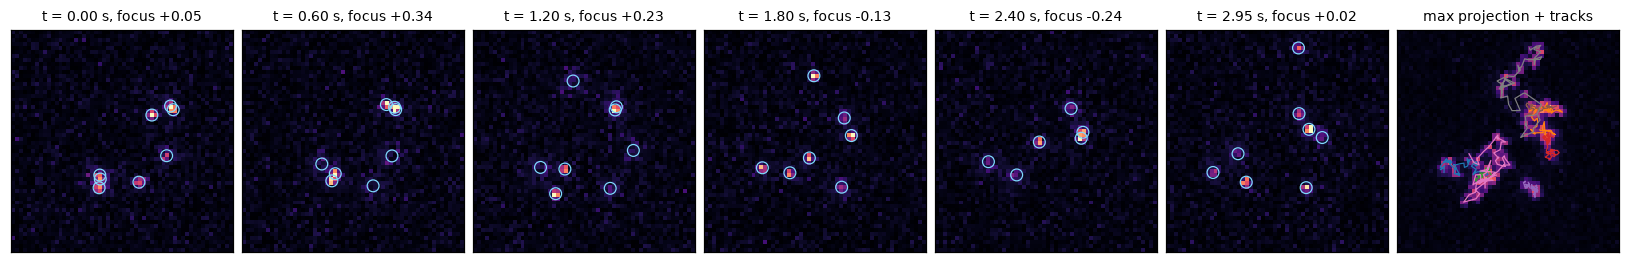

In [4]:
frames = [0, T // 5, 2 * T // 5, 3 * T // 5, 4 * T // 5, T - 1]
low, high = float(movie[0].quantile(0.01)), float(movie[0].quantile(0.9995))
fig, axes = plt.subplots(
    1, len(frames) + 1, figsize=(2.1 * (len(frames) + 1), 2.6), layout="constrained"
)
for ax, t in zip(axes, frames, strict=False):
    ax.imshow(to_numpy(movie[0, t, 0]), cmap="magma", vmin=low, vmax=high)
    visible = (table[0, t, :, 4] > 0) & (table[0, t, :, 3] > 0)  # present and switched on
    ax.scatter(
        to_numpy(table[0, t, visible, 0]),
        to_numpy(table[0, t, visible, 1]),
        s=60,
        facecolors="none",
        edgecolors="#7fdbff",
        linewidths=0.8,
    )
    ax.set_title(f"t = {t * dt:.2f} s, focus {float(focus[0, t]):+.2f}")
    ax.set_xticks([])
    ax.set_yticks([])
axes[-1].imshow(to_numpy(movie[0, :, 0].amax(dim=0)), cmap="magma")
for n in range(N):  # the table's pixel positions trace the tracks on the projection
    axes[-1].plot(to_numpy(table[0, :, n, 0]), to_numpy(table[0, :, n, 1]), lw=0.8)
axes[-1].set_title("max projection + tracks")
axes[-1].set_xticks([])
axes[-1].set_yticks([])
plt.show()

## 3. Check the ground truth

The labels are ground truth for training, so they should reproduce the physics that generated
them. Lateral mean squared displacements from the table's pixel positions grow as `4·D·τ` for each
particle's own D (up to the chamber, which only bounds z). And the focus drift shows in the
images: a particle's peak brightness falls as it moves away from the focal plane.

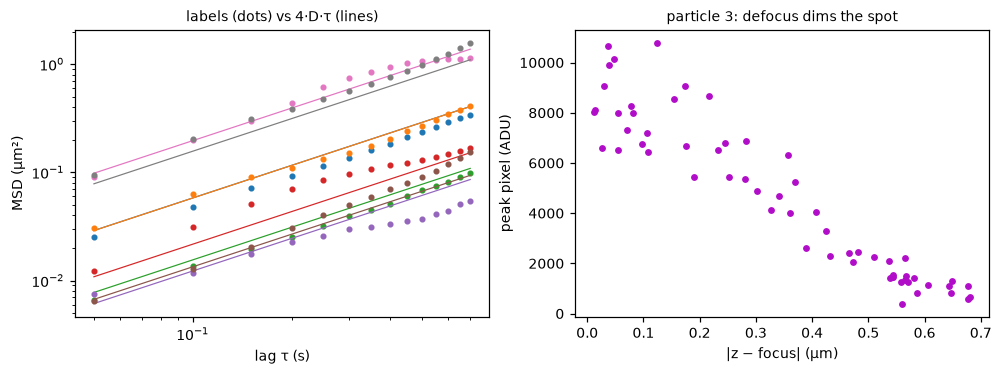

In [5]:
pitch = float(gx.coords.pitch(camera, objective))
xy = table[..., :2] * pitch  # µm, lateral
lags = torch.arange(1, max(2, T // 4))
msd = torch.stack([((xy[:, lag:] - xy[:, :-lag]) ** 2).sum(-1).mean(dim=1) for lag in lags], -1)

fig, (left, right) = plt.subplots(1, 2, figsize=(9.0, 3.3), layout="constrained")
for n in range(N):
    line = left.loglog(to_numpy(lags * dt), to_numpy(msd[0, n]), "o", ms=3)
    left.loglog(
        to_numpy(lags * dt),
        to_numpy(4 * D[0, 0, n, 0] * lags * dt),
        "-",
        color=line[0].get_color(),
        lw=0.8,
    )
left.xaxis.set_minor_formatter(NullFormatter())  # decades only: minor labels would overlap
left.set_xlabel("lag τ (s)")
left.set_ylabel("MSD (µm²)")
left.set_title("labels (dots) vs 4·D·τ (lines)")

n = int(torch.argmax(on[0].sum(0)))  # the particle that is on most of the time
rows = table[0, :, n, 1].round().long().clamp(0, camera.shape[0] - 1)
cols = table[0, :, n, 0].round().long().clamp(0, camera.shape[1] - 1)
peak = movie[0, torch.arange(T), 0, rows, cols]
distance = (position[0, :, n, 2] - focus[0]).abs()
lit = on[0, :, n] > 0
right.scatter(to_numpy(distance[lit]), to_numpy(peak[lit]), s=12, color="#b10dc9")
right.set_xlabel("|z − focus| (µm)")
right.set_ylabel("peak pixel (ADU)")
right.set_title(f"particle {n}: defocus dims the spot")
plt.show()

## Recap

- The caller owned the dynamics (diffusion, confinement, blinking, drift) and gradix rendered
  them: per-frame positions and photons, and a per-frame focus setting, under one acquisition.
- Frames and labels come from one Pipeline call, `[B, T, C, H, W]` and `[B, T, N, 5]`, so the
  tables are frame-accurate ground truth for detection, localisation and linking.
- Swap the camera (`gx.Camera.scmos`, `gx.noise.PoissonGaussian`), the imaging element
  (`gx.imaging.Sprites` for speed) or the medium (`gx.env.WaterOnCoverslip` for TIRF-like
  depths) without touching the trajectories.